In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from helpers import plot_segmentation_comparison
from helpers import create_panoptic_test_data

IMPORTANT NOTE: Currently, there is no way to get the value of PQ across all classes in the original way intended just from "API/function" calls. That is because SQ/RQ values which are returned are averaged over all the instances for each class. 

So, I will show the following examples only for binary cases, which kinda defeats the purpose but i guess validates the MaxBipartite Matcher class.

### Thresholds are set to 0.5 for all

Setup Panoptica

In [3]:
from panoptica import (
    InputType,
    Panoptica_Evaluator,
    ConnectedComponentsInstanceApproximator,
    NaiveThresholdMatching
)
from panoptica.utils.segmentation_class import SegmentationClassGroups

#? For Multi Class
def create_evaluator():
    # Define class groups using a more readable dictionary
    groups = {
        "class_1": (1, False),
        "class_2": (2, False),
        "class_3": (3, True),  # True makes this a stuff instance
    }
    class_groups = SegmentationClassGroups(groups)
    
    return Panoptica_Evaluator(
        expected_input=InputType.SEMANTIC,
        instance_approximator=ConnectedComponentsInstanceApproximator(),
        instance_matcher=NaiveThresholdMatching(),
        segmentation_class_groups=class_groups,
    )

def panoptica_results_naive(pred_masks, ref_masks):

    evaluator = Panoptica_Evaluator(
    expected_input=InputType.SEMANTIC,
    instance_approximator=ConnectedComponentsInstanceApproximator(),
    instance_matcher=NaiveThresholdMatching(matching_threshold=0.0),)

    pred_masks = pred_masks.astype(np.int32)
    ref_masks = ref_masks.astype(np.int32)
    
    evaluator = create_evaluator() #! This is for multi class
    results = evaluator.evaluate(pred_masks.astype(int), ref_masks.astype(int), verbose=False) #! This is for multi class
    
    #? For single class
    # results = evaluator.evaluate(pred_masks.astype(int), ref_masks.astype(int), verbose=False)['ungrouped']
    # print(f"{results.pq=} | {results.tp=} | {results.fp=} | {results.fn=}")
    # print()
    
    #! This is for multi class
    for class_name, result in results.items():
        print(f"\n--- {class_name} ---")
        # Use dictionary comprehension with better variable names
        important_metrics = {'pq'}
        metrics = {
            metric: round(value, 4) if isinstance(value, float) else value
            for metric, value in result.to_dict().items() 
            if metric in important_metrics
        }
        print(metrics)

#! Multi Class
def total_pq_from_panoptica(pred_masks, ref_masks):
    """Calculate overall PQ score across all classes."""
    evaluator = create_evaluator()
    results = evaluator.evaluate(pred_masks.astype(int), ref_masks.astype(int), verbose=False)
    
    # Initialize metrics dictionary to store values for each class
    metrics = {
        'pq': [],  # Panoptic Quality
        'sq': [],  # IoU for matched segments
        'tp': [],  # True positives
        'fp': [],  # False positives
        'fn': [],  # False negatives
    }

    print("## Panoptica: ##")
    
    # Collect metrics for each class - store separately
    for class_name, result in results.items():
        result_dict = result.to_dict()
        for metric in metrics:
            metrics[metric].append(result_dict[metric])
        print(f"{class_name} - PQ: {result_dict['pq']}, SQ: {result_dict['sq']}, "
              f"TP: {result_dict['tp']}, FP: {result_dict['fp']}, FN: {result_dict['fn']}")
    
    # Calculate the weighted sum of SQ (multiply each class's SQ by its TP count)
    iou_sum = sum(sq * tp for sq, tp in zip(metrics['sq'], metrics['tp']))
    total_tp = sum(metrics['tp'])
    total_fp = sum(metrics['fp'])
    total_fn = sum(metrics['fn'])
    total_pq = sum(metrics['pq'])  # This is the sum of PQ for each class
    
    # Calculate PQ using your formula
    denominator = total_tp + (0.5 * total_fp) + (0.5 * total_fn)
    numerator = iou_sum  # This is the sum of (SQ * TP) for each class
    # total_pq = numerator / denominator if denominator > 0 else 0
    print(f"Total PQ: {total_pq/3}")
    
    print()
    print('Total Counts:')
    print(f"TP: {total_tp}")
    print(f"FP: {total_fp}")
    print(f"FN: {total_fn}")
    print(f'numerator: {numerator}')
    print(f'denominator: {denominator}')
    
    return total_pq

Setup panopticapi

In [4]:
from panopticapi.evaluation import pq_compute

def panopticapi_results(pred, ref, stuff_cls_list, thing_cls_list):
    """
    Compute panoptic quality using panopticapi
    """
    # Create a dummy dataset
    data_paths = create_panoptic_test_data(pred, ref, stuff_cls_list, thing_cls_list)

    # Run evaluation
    results = pq_compute(
        gt_json_file=data_paths["gt_json"],
        pred_json_file=data_paths["pred_json"],
        gt_folder=data_paths["gt_folder"],
        pred_folder=data_paths["pred_folder"]
    )

    #! For multi class
    # Print per-class details in a more readable format
    print("\nPer-class results (non-zero scores only):")
    print("{:^10}|{:^8}{:^8}{:^8}".format("Class ID", "PQ", "SQ", "RQ"))
    print("-" * 34)

    #! For multi class
    # Get per-class results and filter out zero scores
    per_class = results['per_class']
    non_zero_classes = {class_id: metrics for class_id, metrics in per_class.items() 
                    if metrics['pq'] > 0}

    # Print classes with non-zero scores
    for class_id, metrics in sorted(non_zero_classes.items()):
        print("{:^10}|{:^8.1f}{:^8.1f}{:^8.1f}".format(
            class_id,
            metrics['pq'] * 100,
            metrics['sq'] * 100,
            metrics['rq'] * 100
        ))

Setup

In [5]:
def run(pred_masks, ref_masks, stuff_cls_list, thing_cls_list):
    plot_segmentation_comparison(pred_masks, ref_masks)

    panoptica_results_naive(pred_masks, ref_masks)
    print()
    total_pq_from_panoptica(pred_masks, ref_masks)
    print()

    # print('max')
    # panoptica_results_max(pred_masks, ref_masks)
    # print()
    
    print('## panopticapi ##')
    panopticapi_results(pred_masks, ref_masks, stuff_cls_list, thing_cls_list)
    print()

Case 1: Simple | 100% Score

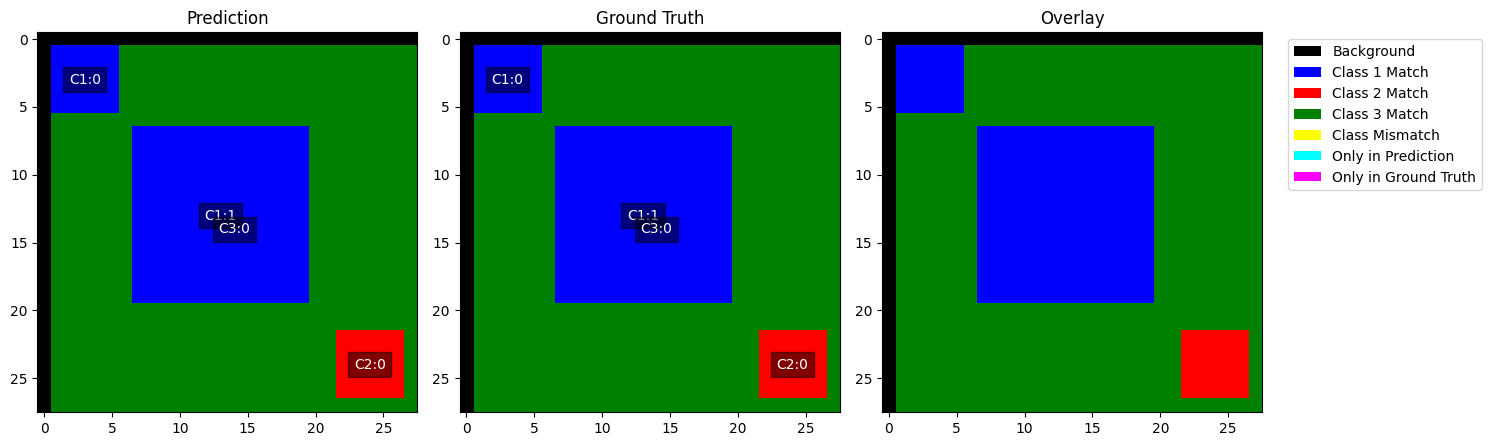

Evaluating group class_1 with labels LabelGroup [1], single_instance=False


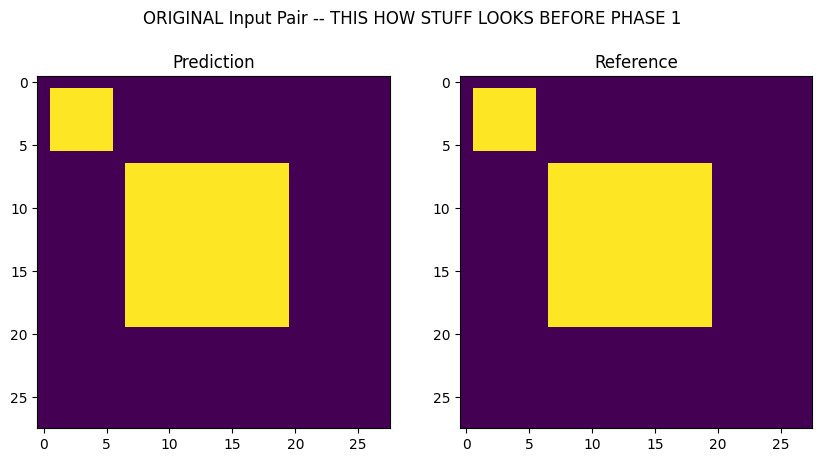

Evaluating group class_2 with labels LabelGroup [2], single_instance=False


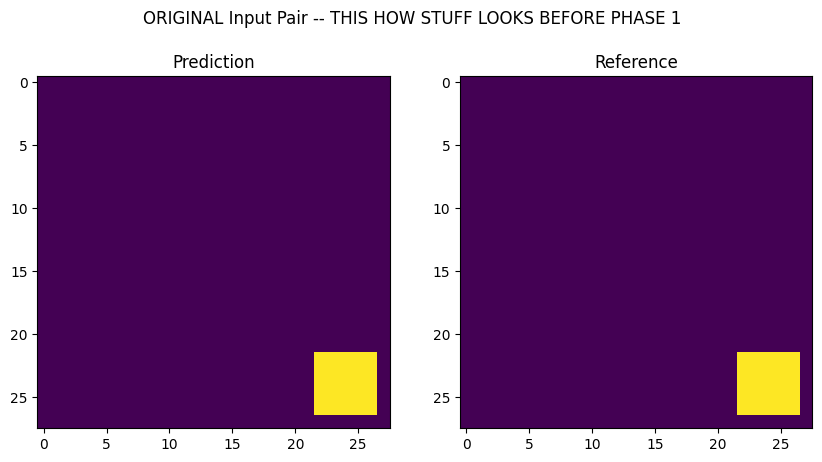

Evaluating group class_3 with labels LabelGroup [3], single_instance=True


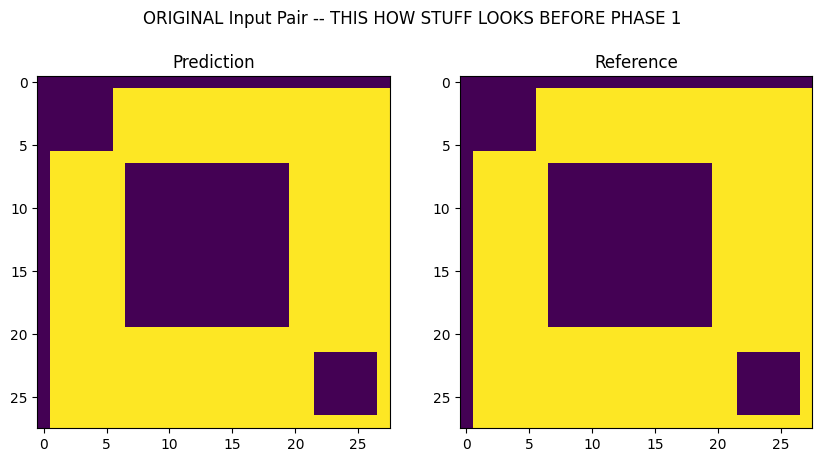


--- class_1 ---
{'pq': 1.0}

--- class_2 ---
{'pq': 1.0}

--- class_3 ---
{'pq': 1.0}

Evaluating group class_1 with labels LabelGroup [1], single_instance=False


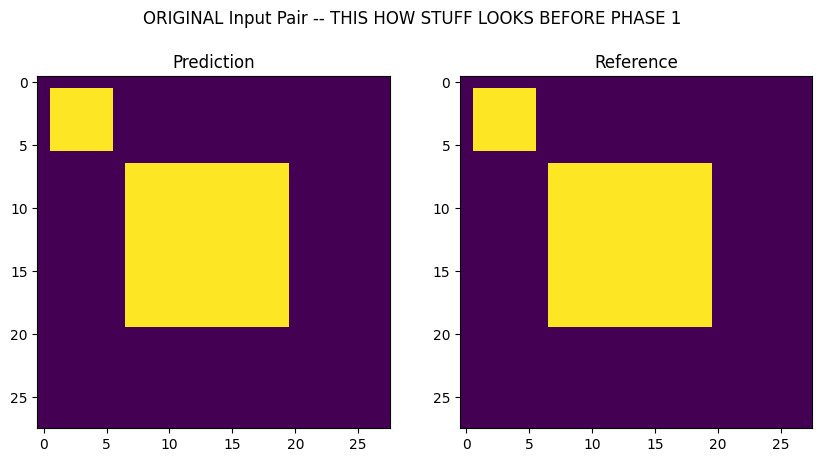

Evaluating group class_2 with labels LabelGroup [2], single_instance=False


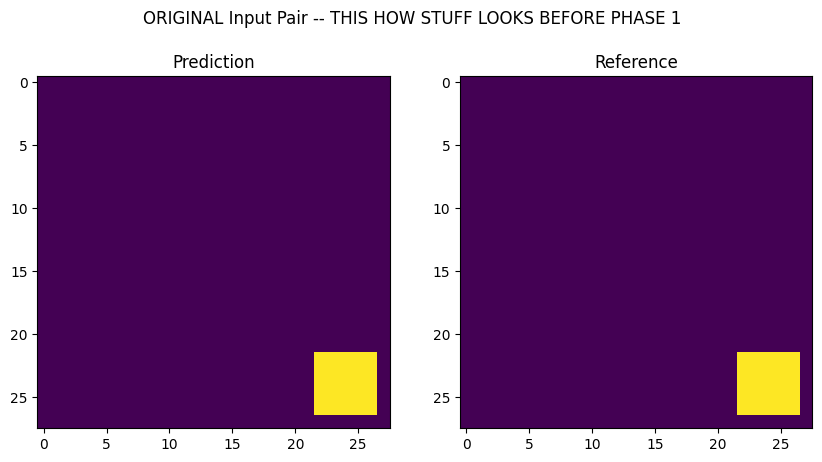

Evaluating group class_3 with labels LabelGroup [3], single_instance=True


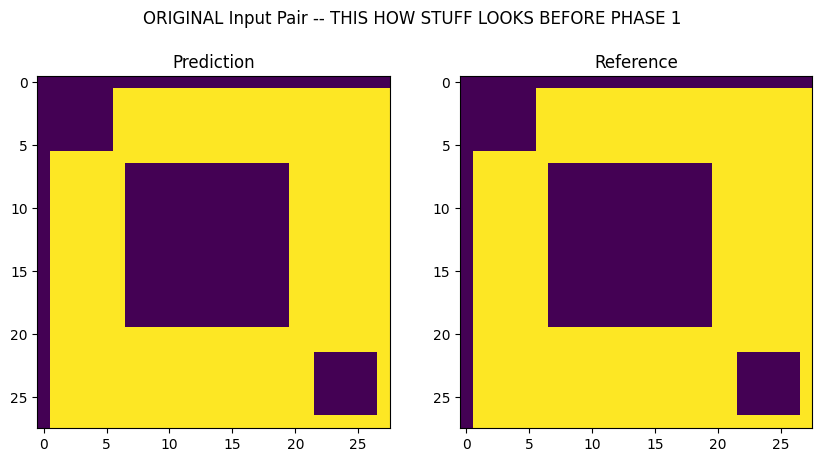

## Panoptica: ##
class_1 - PQ: 1.0, SQ: 1.0, TP: 2, FP: 0, FN: 0
class_2 - PQ: 1.0, SQ: 1.0, TP: 1, FP: 0, FN: 0
class_3 - PQ: 1.0, SQ: 1.0, TP: 1, FP: 0, FN: 0
Total PQ: 1.0

Total Counts:
TP: 4
FP: 0
FN: 0
numerator: 4.0
denominator: 4.0

## panopticapi ##
          |    PQ     SQ     RQ     N
--------------------------------------
All       | 100.0  100.0  100.0     3
Things    | 100.0  100.0  100.0     2
Stuff     | 100.0  100.0  100.0     1

Total counts:
TP: 4
FP: 0
FN: 0
Numerator: 4.0
Denominator: 4.0

Per-class results (non-zero scores only):
 Class ID |   PQ      SQ      RQ   
----------------------------------
    1     | 100.0   100.0   100.0  
    2     | 100.0   100.0   100.0  
    3     | 100.0   100.0   100.0  



In [6]:
# Dummy Case
pred_masks = np.zeros((28, 28))
ref_masks = np.zeros((28, 28))

# Stuff Classes first (lowest hirearchy)
pred_masks[1:30, 1:30] = 3

# Thing Classes next (medium hirearchy)
pred_masks[1:6, 1:6] = 1
pred_masks[7:20, 7:20] = 1
pred_masks[22:27, 22:27] = 2

# Same ordering for ground truth
# Stuff Classes first
ref_masks[1:30, 1:30] = 3

# Thing Classes next
ref_masks[1:6, 1:6] = 1
ref_masks[7:20, 7:20] = 1
ref_masks[22:27, 22:27] = 2

# Class definitions
stuff_cls_list = [3]
thing_cls_list = [1, 2]

run(pred_masks, ref_masks, stuff_cls_list, thing_cls_list)

Case 2: Simple | 1 class is 0

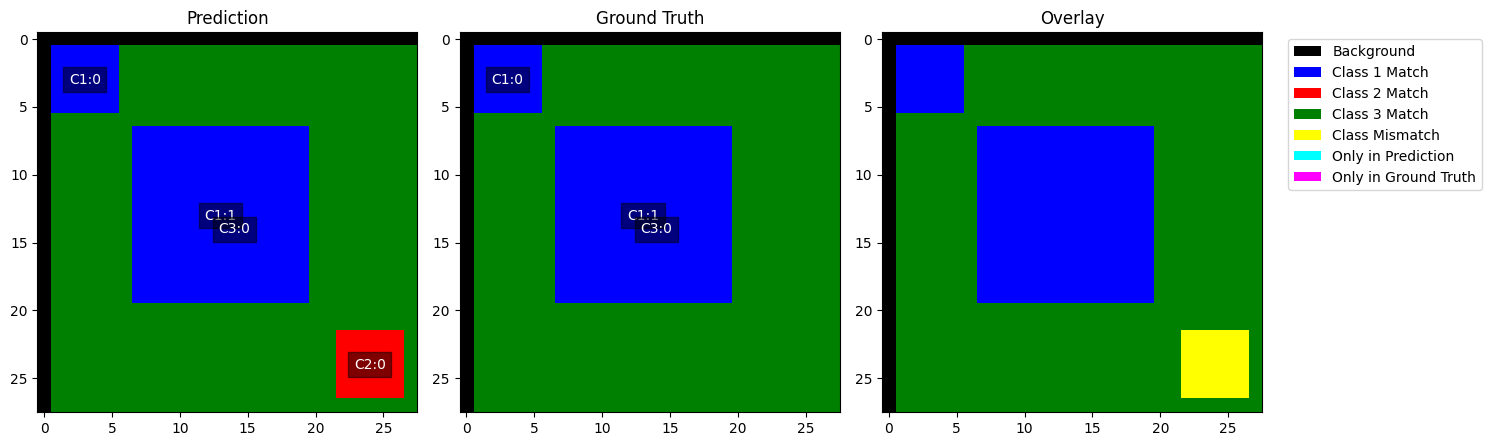

Evaluating group class_1 with labels LabelGroup [1], single_instance=False


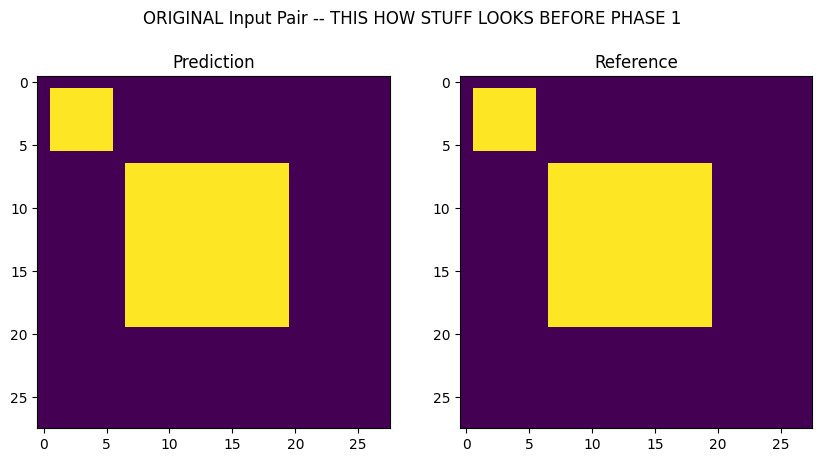

Evaluating group class_2 with labels LabelGroup [2], single_instance=False


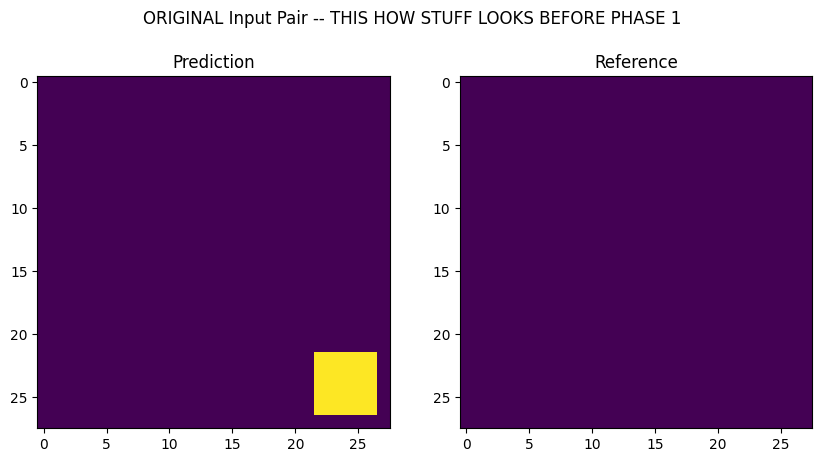

Evaluating group class_3 with labels LabelGroup [3], single_instance=True


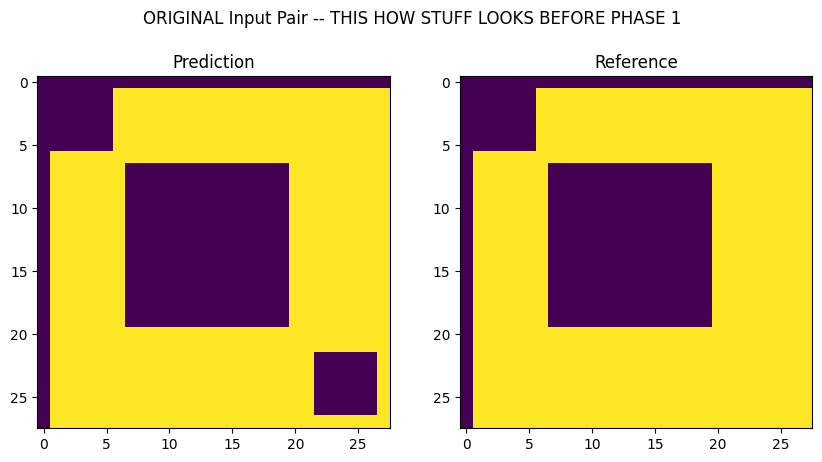


--- class_1 ---
{'pq': 1.0}

--- class_2 ---
{'pq': 0.0}

--- class_3 ---
{'pq': 0.9533}

Evaluating group class_1 with labels LabelGroup [1], single_instance=False


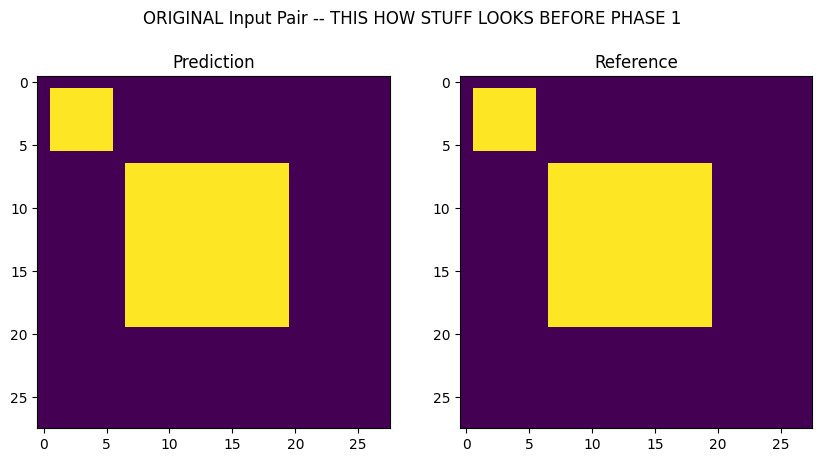

Evaluating group class_2 with labels LabelGroup [2], single_instance=False


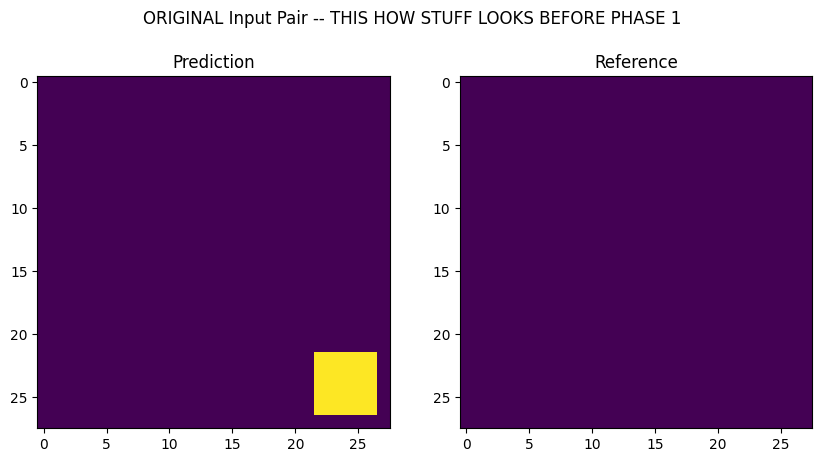

Evaluating group class_3 with labels LabelGroup [3], single_instance=True


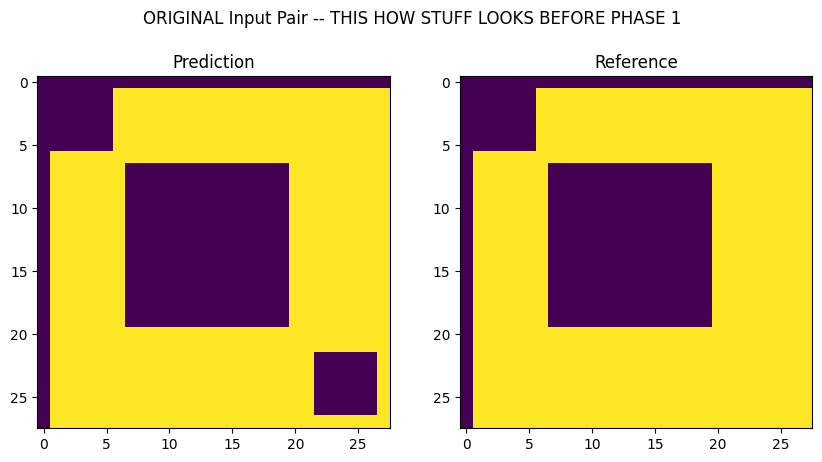

## Panoptica: ##
class_1 - PQ: 1.0, SQ: 1.0, TP: 2, FP: 0, FN: 0
class_2 - PQ: 0.0, SQ: 0.0, TP: 0, FP: 1, FN: 0
class_3 - PQ: 0.9532710280373832, SQ: 0.9532710280373832, TP: 1, FP: 0, FN: 0
Total PQ: 0.6510903426791277

Total Counts:
TP: 3
FP: 1
FN: 0
numerator: 2.953271028037383
denominator: 3.5

## panopticapi ##
          |    PQ     SQ     RQ     N
--------------------------------------
All       |  65.1   65.1   66.7     3
Things    |  50.0   50.0   50.0     2
Stuff     |  95.3   95.3  100.0     1

Total counts:
TP: 3
FP: 1
FN: 0
Numerator: 2.953271028037383
Denominator: 3.5

Per-class results (non-zero scores only):
 Class ID |   PQ      SQ      RQ   
----------------------------------
    1     | 100.0   100.0   100.0  
    3     |  95.3    95.3   100.0  



In [7]:
# Dummy Case
pred_masks = np.zeros((28, 28))
ref_masks = np.zeros((28, 28))

# Stuff Classes first (lowest hirearchy)
pred_masks[1:30, 1:30] = 3

# Thing Classes next (medium hirearchy)
pred_masks[1:6, 1:6] = 1
pred_masks[7:20, 7:20] = 1
pred_masks[22:27, 22:27] = 2

# Same ordering for ground truth
# Stuff Classes first
ref_masks[1:30, 1:30] = 3

# Thing Classes next
ref_masks[1:6, 1:6] = 1
ref_masks[7:20, 7:20] = 1
# ref_masks[22:27, 22:27] = 2

# Class definitions
stuff_cls_list = [3]
thing_cls_list = [1, 2]

run(pred_masks, ref_masks, stuff_cls_list, thing_cls_list)

Case 3: Complex

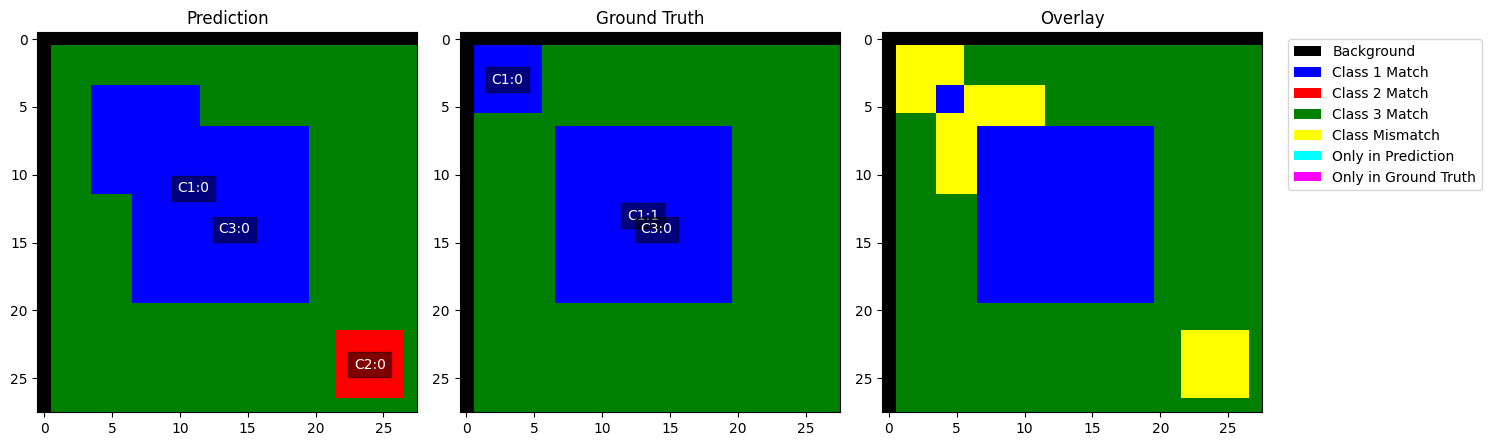

Evaluating group class_1 with labels LabelGroup [1], single_instance=False


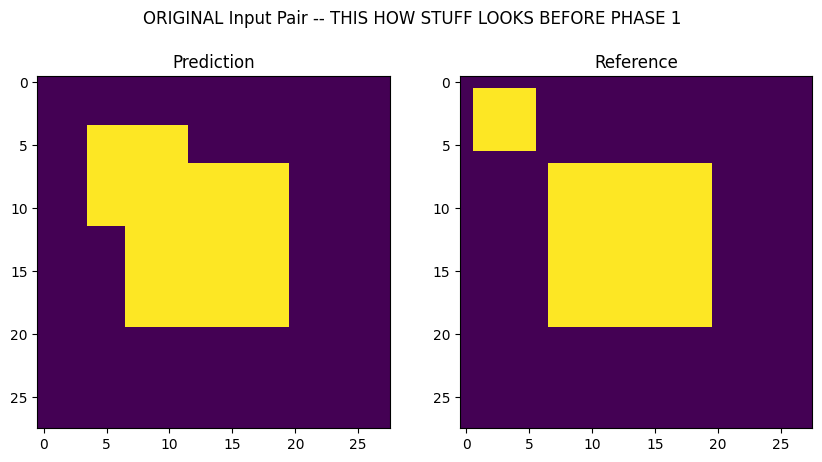

Evaluating group class_2 with labels LabelGroup [2], single_instance=False


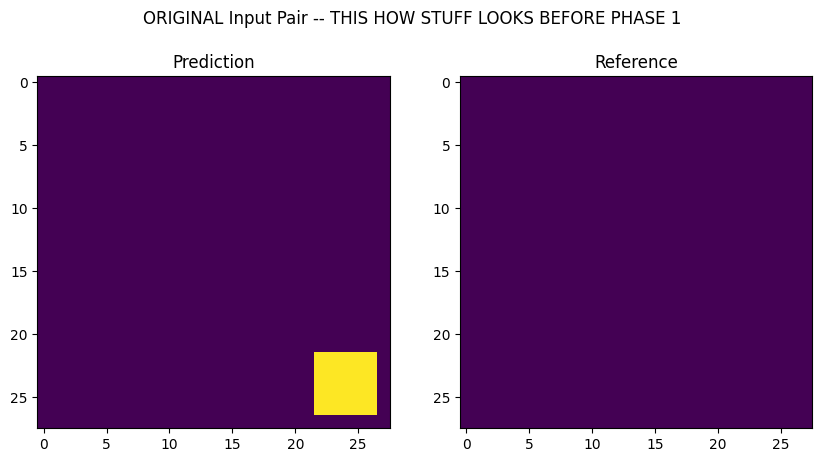

Evaluating group class_3 with labels LabelGroup [3], single_instance=True


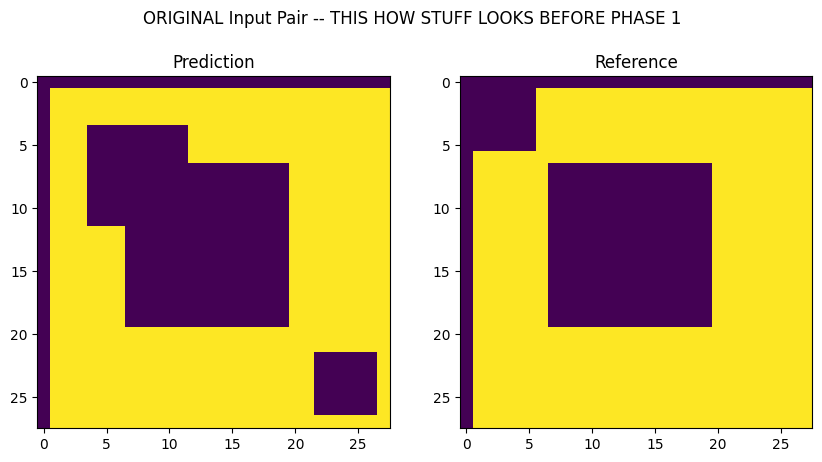


--- class_1 ---
{'pq': 0.5417}

--- class_2 ---
{'pq': 0.0}

--- class_3 ---
{'pq': 0.8543}

Evaluating group class_1 with labels LabelGroup [1], single_instance=False


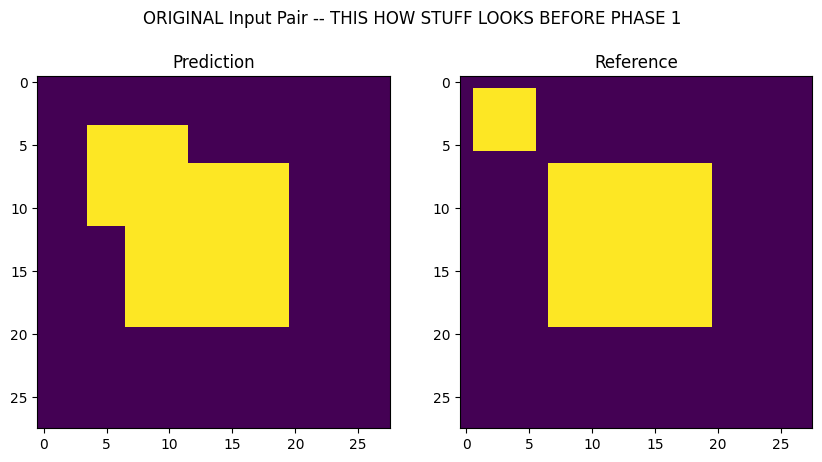

Evaluating group class_2 with labels LabelGroup [2], single_instance=False


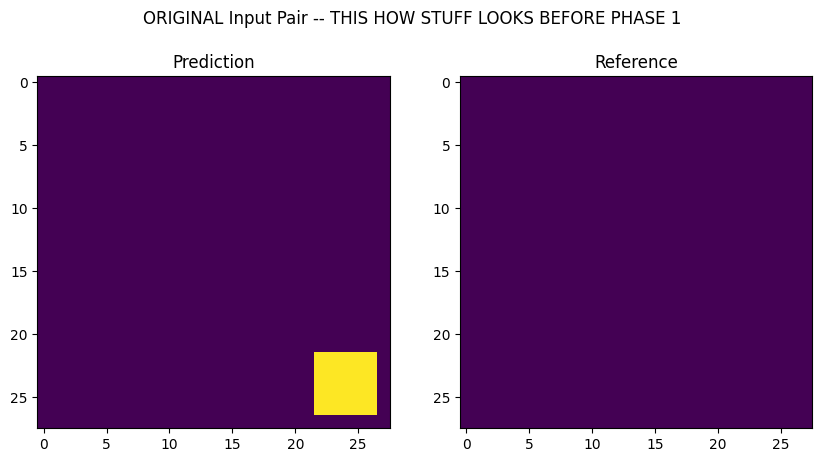

Evaluating group class_3 with labels LabelGroup [3], single_instance=True


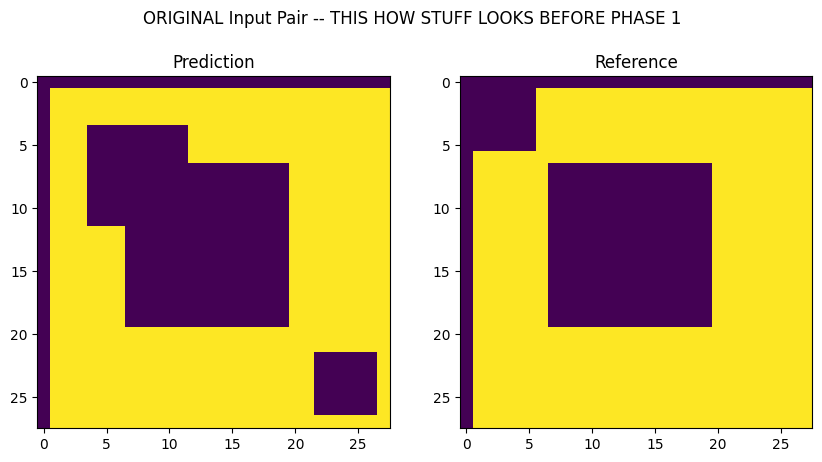

## Panoptica: ##
class_1 - PQ: 0.5416666666666666, SQ: 0.8125, TP: 1, FP: 0, FN: 1
class_2 - PQ: 0.0, SQ: 0.0, TP: 0, FP: 1, FN: 0
class_3 - PQ: 0.85431654676259, SQ: 0.85431654676259, TP: 1, FP: 0, FN: 0
Total PQ: 0.46532773780975223

Total Counts:
TP: 2
FP: 1
FN: 1
numerator: 1.66681654676259
denominator: 3.0

## panopticapi ##
          |    PQ     SQ     RQ     N
--------------------------------------
All       |  46.5   55.6   55.6     3
Things    |  27.1   40.6   33.3     2
Stuff     |  85.4   85.4  100.0     1

Total counts:
TP: 2
FP: 1
FN: 1
Numerator: 1.66681654676259
Denominator: 3.0

Per-class results (non-zero scores only):
 Class ID |   PQ      SQ      RQ   
----------------------------------
    1     |  54.2    81.2    66.7  
    3     |  85.4    85.4   100.0  



In [8]:
# Dummy Case
pred_masks = np.zeros((28, 28))
ref_masks = np.zeros((28, 28))

# Stuff Classes first (lowest hirearchy)
pred_masks[1:30, 1:30] = 3

# Thing Classes next (medium hirearchy)
pred_masks[4:12, 4:12] = 1
pred_masks[7:20, 7:20] = 1
pred_masks[22:27, 22:27] = 2

# Same ordering for ground truth
# Stuff Classes first
ref_masks[1:30, 1:30] = 3

# Thing Classes next
ref_masks[1:6, 1:6] = 1
ref_masks[7:20, 7:20] = 1
# ref_masks[22:27, 22:27] = 2

# Class definitions
stuff_cls_list = [3]
thing_cls_list = [1, 2]

run(pred_masks, ref_masks, stuff_cls_list, thing_cls_list)